# 02 - Workload Forecasting

Loads the frozen GRU forecaster's saved metrics and training history (`results/forecasting/`). Does not retrain the model -- see `src/forecasting/train_forecaster.py` for that. Full methodology in `docs/forecasting_design.md`.

In [1]:
import sys, json
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import Image, display, Markdown

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / "src"))
RESULTS = REPO_ROOT / "results"
DOCS = REPO_ROOT / "docs"
DATA = REPO_ROOT / "data" / "processed"


## Forecast metrics: GRU vs. baselines (test split)

In [2]:
pd.read_csv(RESULTS / 'tables' / '02_forecast_metrics.csv')

,model,n,mae,rmse,r2
0,gru,1737,0.007424,0.011235,-0.013670
1,persistence,1737,0.008587,0.015783,-1.000271
2,moving_average,1737,0.007464,0.012296,-0.214104


**Honest interpretation** (see `docs/forecasting_design.md`): the GRU beats persistence and moving-average on MAE/RMSE, but its R² is close to zero. Better MAE/RMSE does **not** imply strong explanatory power when R² is near zero -- both facts are reported together deliberately.

## Training/validation loss curve

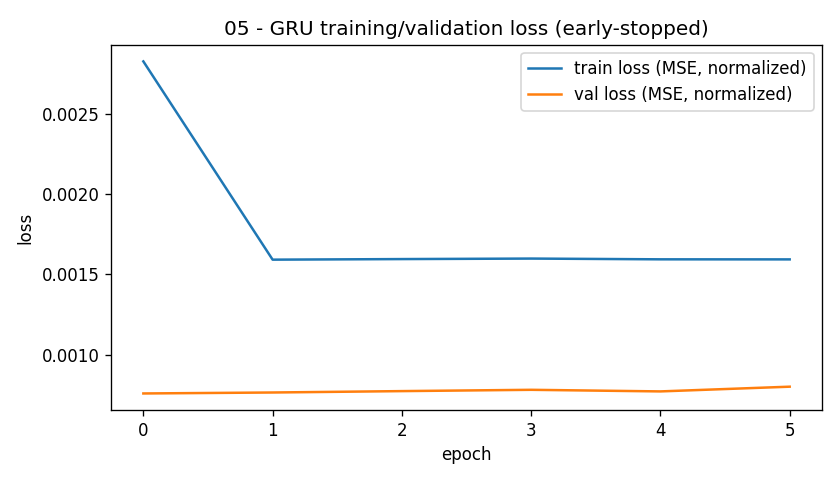

In [3]:
display(Image(filename=str(RESULTS / 'figures' / '05_gru_training_loss.png')))

## Forecast vs. true future workload, example windows

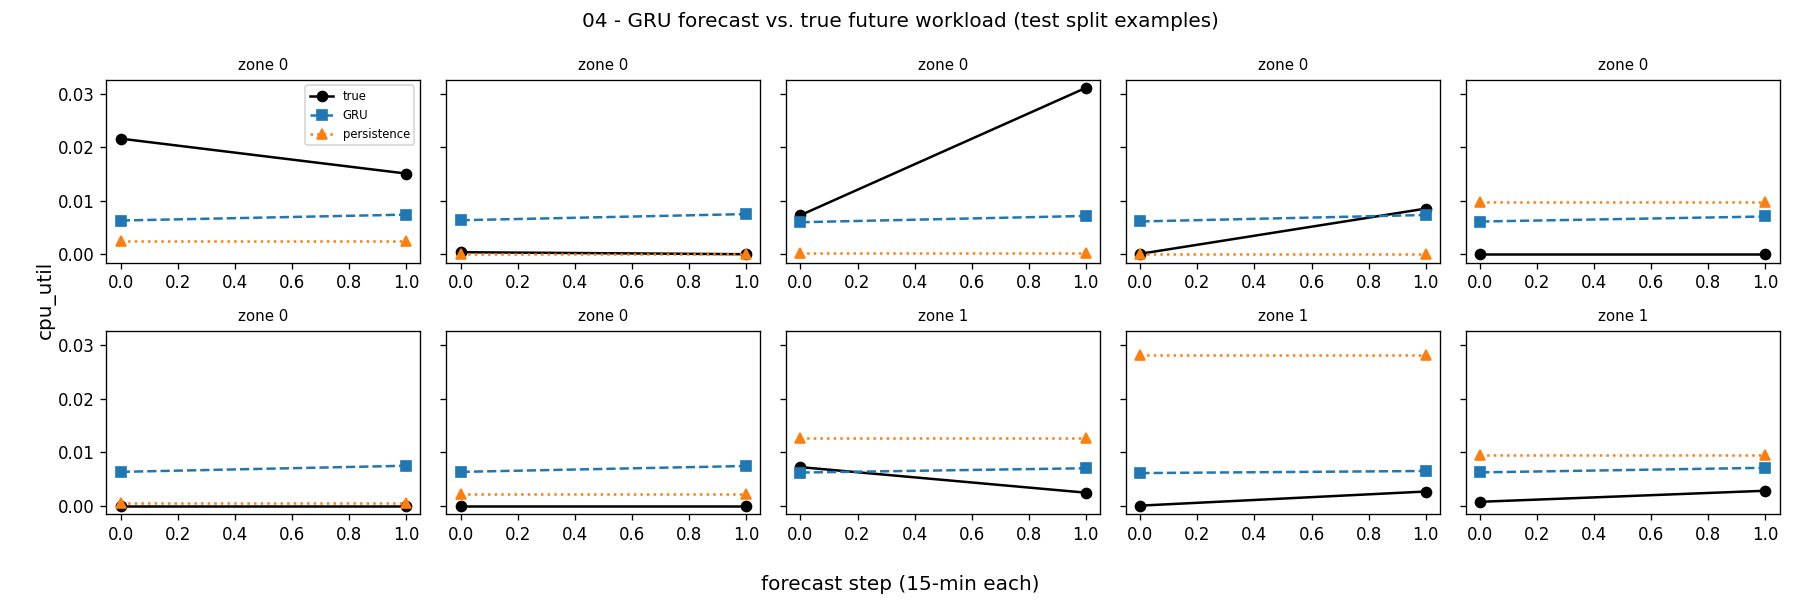

In [4]:
display(Image(filename=str(RESULTS / 'figures' / '04_gru_forecast_vs_actual.png')))

## Causality check

`docs/leakage_audit.md` programmatically verifies the forecast is never a copy of the true future and the scaler is fit on the training split only.

In [5]:
print((DOCS / 'leakage_audit.md').read_text()[:600])

# Data Leakage Audit — Phase 34 / Final Handoff Audit

## Final status: PASS

**11/11 checks passed.**

- PASS — chronological split (train < val < test bin_id)
  - Evidence: train max=1785, val range=[1786,2380], test min=2381

- PASS — forecast window target strictly follows input (no overlap)
  - Evidence: checked on synthetic monotonic series, target always > input max

- PASS — forecast scaler fit only on X_train (not val/test)
  - Evidence: static source check: min/max computed from X_train only, before any val/test min/max call

- PASS — RL observation unaffected by corrupting far-futur
